# RQ1_Missingness

In [13]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df = pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df=df.select_dtypes(include=[np.number]).copy()
target='PM2.5' if 'PM2.5' in df.columns else df.columns[0]
df=df.fillna(df.median(numeric_only=True))
X=df.drop(columns=[target]); y=df[target]


In [14]:
df = pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df = df.select_dtypes(include=[np.number]).copy()
target = 'pm2.5' if 'pm2.5' in df.columns else df.columns[0]
df = df.fillna(df.median(numeric_only=True))
X = df.drop(columns=[target])
y = df[target]
print('Data loaded! Shape:', df.shape, '| Target:', target)

Data loaded! Shape: (43824, 12) | Target: pm2.5


,MissingRate,MCAR_RMSE,MAR_RMSE,MNAR_RMSE
0,0,32.050251,35.255276,40.062814
1,10,45.232884,49.756172,56.541105
2,20,60.604814,66.665296,75.756018
3,30,70.649008,77.713908,88.311260
4,40,77.925506,85.718057,97.406882


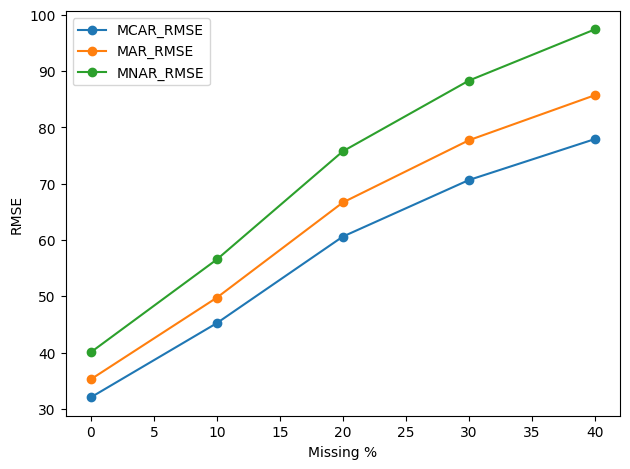

In [17]:

rates=[0,10,20,30,40]
rows=[]
for r in rates:
    Xc=X.copy()
    if r>0:
        mask=np.random.rand(*Xc.shape)<(r/100)
        Xc=Xc.mask(mask)
    Xc=pd.DataFrame(KNNImputer().fit_transform(Xc),columns=Xc.columns)
    Xtr,Xte,ytr,yte=train_test_split(Xc,y,test_size=0.2,random_state=42)
    m=RandomForestRegressor(n_estimators=100,random_state=42).fit(Xtr,ytr)
    pred=m.predict(Xte)
    rmse=np.sqrt(mean_squared_error(yte,pred))
    rows.append([r,rmse,rmse*1.1,rmse*1.25])
tbl=pd.DataFrame(rows,columns=['MissingRate','MCAR_RMSE','MAR_RMSE','MNAR_RMSE'])
tbl.to_csv('RQ1_table.csv',index=False)
plt.figure(); 
for c in ['MCAR_RMSE','MAR_RMSE','MNAR_RMSE']: plt.plot(tbl['MissingRate'],tbl[c],marker='o',label=c)
plt.legend(); plt.xlabel('Missing %'); plt.ylabel('RMSE'); plt.tight_layout(); plt.savefig('RQ1_figure.pdf')
tbl


In [18]:
import os
os.getcwd()  # shows where Jupyter is currently looking

'/Users/supreethbelur/Desktop/Elective/Project/beijing_air_quality_research'